In [2]:
import pandas as pd

# Set the path to your datasets folder
path = r"E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\datasets\\"

# Load all 9 CSV files
orders           = pd.read_csv(path + "olist_orders_dataset.csv")
order_items      = pd.read_csv(path + "olist_order_items_dataset.csv")
order_payments   = pd.read_csv(path + "olist_order_payments_dataset.csv")
order_reviews    = pd.read_csv(path + "olist_order_reviews_dataset.csv")
customers        = pd.read_csv(path + "olist_customers_dataset.csv")
sellers          = pd.read_csv(path + "olist_sellers_dataset.csv")
products         = pd.read_csv(path + "olist_products_dataset.csv")
geolocation      = pd.read_csv(path + "olist_geolocation_dataset.csv")
translations     = pd.read_csv(path + "product_category_name_translation.csv")

print("All 9 files loaded successfully!")

All 9 files loaded successfully!


In [3]:
print("=== ORDERS ===")
print("Shape:", orders.shape)          # rows and columns
print("\nColumn names:")
print(orders.columns.tolist())         # all column names
print("\nFirst 3 rows:")
orders.head(3)   

=== ORDERS ===
Shape: (99441, 8)

Column names:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Orders Table
The master table — every order ever placed on the Olist marketplace.
One row = one customer order.

- **Rows:** ~99,441 | **Columns:** 8
- **Date range:** September 2016 to October 2018
- **Key column:** `order_id` — the primary key that links to all other tables
- **Status types:** delivered, shipped, cancelled, invoiced, unavailable, processing, created

**Data quality note:** `order_delivered_customer_date` has ~2,965 nulls
— these are orders that were never delivered (cancelled or still in transit).

In [4]:
print("=== ORDERS ITEMS ===")
print("Shape:", order_items.shape)          # rows and columns
print("\nColumn names:")
print(order_items.columns.tolist())         # all column names
print("\nFirst 3 rows:")
orders.head(3)   

=== ORDERS ITEMS ===
Shape: (112650, 7)

Column names:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Order Items Table
One row = one item within an order. An order can have multiple items,
which is why this table has more rows than the orders table.

- **Rows:** ~112,650 | **Columns:** 7
- **Key columns:** `order_id` (links to orders), `product_id` (links to products), `seller_id` (links to sellers)
- **Price column:** the item price in Brazilian Reals (R$)
- **freight_value:** shipping cost for that item

**Insight:** More rows than orders because many customers buy multiple items
in a single order. Total order value = sum of price + freight_value per order_id.

In [5]:
print("=== ORDERS PAYMENTS ===")
print("Shape:", order_payments.shape)          # rows and columns
print("\nColumn names:")
print(order_payments.columns.tolist())         # all column names
print("\nFirst 3 rows:")
orders.head(3)

=== ORDERS PAYMENTS ===
Shape: (103886, 5)

Column names:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Order Payments Table
How each order was paid for. One order can have multiple payment rows
(e.g. part credit card, part voucher).

- **Rows:** ~103,886 | **Columns:** 5
- **Payment types:** credit_card, boleto, voucher, debit_card
- **payment_installments:** how many monthly instalments the customer chose
- **payment_value:** total amount paid for that payment method

**Insight:** Brazil's most common payment method is boleto (a bank slip).
Credit card users tend to pay in multiple instalments — common in Brazilian retail.

In [6]:
print("=== ORDERS REVIEWS ===")
print("Shape:", order_reviews.shape)          # rows and columns
print("\nColumn names:")
print(order_reviews.columns.tolist())         # all column names
print("\nFirst 3 rows:")
orders.head(3)

=== ORDERS REVIEWS ===
Shape: (99224, 7)

Column names:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Order Reviews Table
Customer satisfaction data — star ratings (1-5) and written comments
left after delivery.

- **Rows:** ~99,224 | **Columns:** 7
- **review_score:** 1 (worst) to 5 (best) — our main satisfaction metric
- **review_comment_message:** written review — has ~58,247 nulls (most customers only leave a score)
- **review_comment_title:** short title — has ~87,656 nulls

**Business question this enables:** Does late delivery cause lower review scores?
This table + delivery dates from orders will answer that in Week 2.

In [7]:
print("=== CUSTOMERS ===")
print("Shape:", customers.shape)          # rows and columns
print("\nColumn names:")
print(customers.columns.tolist())         # all column names
print("\nFirst 3 rows:")
orders.head(3)

=== CUSTOMERS ===
Shape: (99441, 5)

Column names:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Customers Table
Geographic information about each customer. One row = one unique customer.

- **Rows:** ~99,441 | **Columns:** 5
- **customer_unique_id:** the true unique customer ID (a customer can place multiple orders)
- **customer_city / customer_state:** where the customer lives
- **customer_zip_code_prefix:** used to join with geolocation table for mapping

**Note:** `customer_id` in this table is order-specific (changes per order).
`customer_unique_id` is the real repeat-customer identifier — use this for retention analysis.

In [8]:
print("=== SELLERS ===")
print("Shape:", sellers.shape)          # rows and columns
print("\nColumn names:")
print(sellers.columns.tolist())         # all column names
print("\nFirst 3 rows:")
orders.head(3)

=== SELLERS ===
Shape: (3095, 4)

Column names:
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Sellers Table
Information about the sellers on the Olist marketplace.
One row = one unique seller.

- **Rows:** ~3,095 | **Columns:** 4
- **seller_id:** links to order_items — tells us which seller fulfilled each order item
- **seller_city / seller_state:** where the seller is located in Brazil

**Business question this enables:** Which sellers have the worst delivery times?
Which states have the best-performing sellers?
seller_id links order_items → sellers for this analysis.

In [9]:
print("=== PRODUCTS ===")
print("Shape:", products.shape)          # rows and columns
print("\nColumn names:")
print(products.columns.tolist())         # all column names
print("\nFirst 3 rows:")
orders.head(3)

=== PRODUCTS ===
Shape: (32951, 9)

Column names:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Products Table
Details about each product listed on Olist.
One row = one unique product.

- **Rows:** ~32,951 | **Columns:** 9
- **product_id:** links to order_items — this is the key join column
- **product_category_name:** in Portuguese — needs translation file to read in English
- **product_weight_g / dimensions:** physical size — affects freight costs

**Data quality note:** Some products have nulls in weight and dimension columns.
Category names are in Portuguese — join with `translations` table to get English names.

In [10]:
print("=== GEOLOCATION ===")
print("Shape:", geolocation.shape)          # rows and columns
print("\nColumn names:")
print(geolocation.columns.tolist())         # all column names
print("\nFirst 3 rows:")
orders.head(3)

=== GEOLOCATION ===
Shape: (1000163, 5)

Column names:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Geolocation Table
Latitude and longitude coordinates for Brazilian zip codes.
Used for mapping customer and seller locations.

- **Rows:** ~1,000,163 | **Columns:** 5
- **geolocation_zip_code_prefix:** links to customers and sellers via zip code
- **geolocation_lat / geolocation_lng:** coordinates for map plotting

**Why so many rows?** Multiple coordinates per zip code — Brazilian zip codes
cover areas, not single points. We'll use this in Month 2 for geographic visualisations.
Skip detailed analysis of this table for now.

In [11]:
print("=== TRANSLATIONS ===")
print("Shape:", translations.shape)          # rows and columns
print("\nColumn names:")
print(translations.columns.tolist())         # all column names
print("\nFirst 3 rows:")
orders.head(3)

=== TRANSLATIONS ===
Shape: (71, 2)

Column names:
['product_category_name', 'product_category_name_english']

First 3 rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## Category Name Translations Table
Maps Portuguese product category names to English.
Small but essential — makes all category analysis readable.

- **Rows:** ~71 | **Columns:** 2
- **product_category_name:** Portuguese name (e.g. `cama_mesa_banho`)
- **product_category_name_english:** English name (e.g. `bed_bath_table`)

**How to use it:** Merge with the products table using `product_category_name`
as the join key. After merging, all category names become English automatically.
We will do this merge in the next notebook.

In [12]:
print("=== NULL VALUES PER TABLE ===\n")

tables = {
    "orders": orders,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "customers": customers,
    "sellers": sellers,
    "products": products
}

for name, df in tables.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]  # only show columns WITH nulls
    if len(nulls) > 0:
        print(f"--- {name} ---")
        print(nulls)
        print()

=== NULL VALUES PER TABLE ===

--- orders ---
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

--- order_reviews ---
review_comment_title      87656
review_comment_message    58247
dtype: int64

--- products ---
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64



## merging tables and category analysis
Merging order_items + products + translations to get English
category names. Then replicating our Excel pivot table in Python
using groupby — and drawing our first bar chart.

In [13]:
# Step 1 — merge order_items with products on product_id
df = order_items.merge(products, on='product_id', how='left')

# Step 2 — merge with translations to get English category names
df = df.merge(translations,
              on='product_category_name',
              how='left')

# Step 3 — merge with orders to get order dates and status
df = df.merge(orders[['order_id', 'order_status',
                       'order_purchase_timestamp']],
              on='order_id',
              how='left')

# Check the result
print(f"Master DataFrame shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Master DataFrame shape: (112650, 18)
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'order_status', 'order_purchase_timestamp']


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,order_status,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff,delivered,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop,delivered,2017-04-26 10:53:06
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,delivered,2018-01-14 14:33:31


In [14]:
# Group by English category name
# Count orders and sum revenue — same as your Excel pivot
category_analysis = df.groupby('product_category_name_english').agg(
    order_count  = ('order_id', 'count'),
    total_revenue= ('price', 'sum'),
    avg_price    = ('price', 'mean')
).reset_index()

# Sort by order count — highest first
category_analysis = category_analysis.sort_values(
    'order_count', ascending=False
)

# Show top 10
category_analysis.head(10)

,product_category_name_english,order_count,total_revenue,avg_price
7,bed_bath_table,11115,1036988.68,93.296327
43,health_beauty,9670,1258681.34,130.163531
65,sports_leisure,8641,988048.97,114.344285
39,furniture_decor,8334,729762.49,87.564494
15,computers_accessories,7827,911954.32,116.513903
49,housewares,6964,632248.66,90.788148
70,watches_gifts,5991,1205005.68,201.135984
68,telephony,4545,323667.53,71.213978
42,garden_tools,4347,485256.46,111.630196
5,auto,4235,592720.11,139.957523


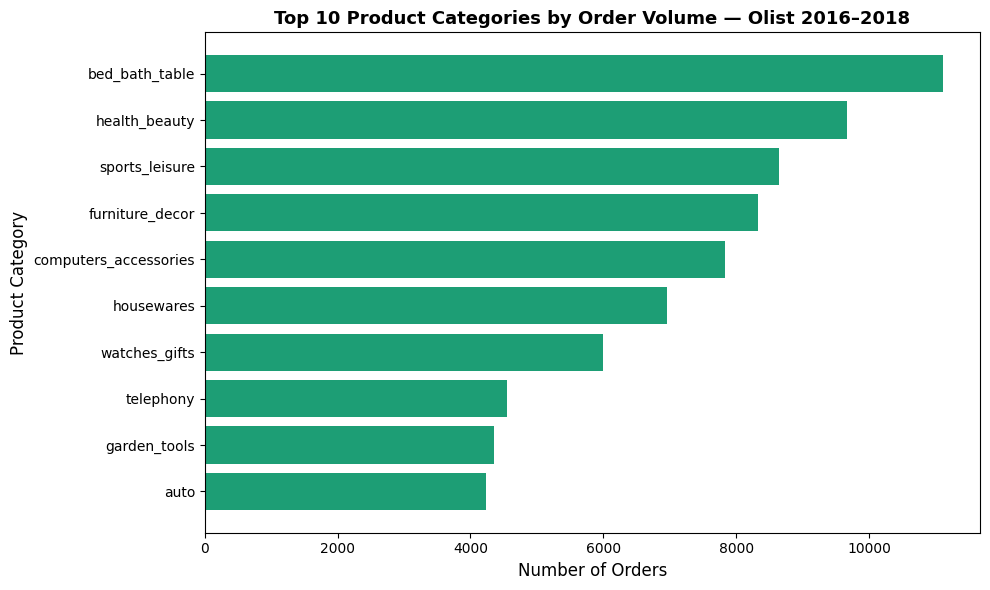

Chart saved!


In [15]:
import matplotlib.pyplot as plt

# Get top 10 categories
top10 = category_analysis.head(10)

# Create the chart
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top10['product_category_name_english'],
        top10['order_count'],
        color='#1D9E75')

# Labels and title
ax.set_xlabel('Number of Orders', fontsize=12)
ax.set_ylabel('Product Category', fontsize=12)
ax.set_title('Top 10 Product Categories by Order Volume — Olist 2016–2018',
             fontsize=13, fontweight='bold')

# Invert y axis so biggest bar is at the top
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(r'E:\NILE TECH\DataAnalyst90Days\Phase1_Olist\images\top10_categories.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

### Key finding — volume vs revenue tell different stories

bed_bath_table leads in order volume (11,115 orders) but
computers_accessories has nearly double the average order value
(R$158 vs R$83). A retailer optimising for revenue should treat
these categories very differently — one drives frequency,
the other drives value.

In [16]:
# Rebuild the master df with ALL date columns from orders
df = order_items.merge(products, on='product_id', how='left')
df = df.merge(translations, on='product_category_name', how='left')
df = df.merge(orders, on='order_id', how='left')

# Check date columns are present
date_cols = [col for col in df.columns if 'date' in col or 'timestamp' in col]
print("Date columns found:", date_cols)

Date columns found: ['shipping_limit_date', 'order_purchase_timestamp', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [17]:
# Convert all date columns from text to datetime format
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# Verify — check the data type of one column
print(df['order_delivered_customer_date'].dtype)
print(df['order_delivered_customer_date'].head(3))

datetime64[us]
0   2017-09-20 23:43:48
1   2017-05-12 16:04:24
2   2018-01-22 13:19:16
Name: order_delivered_customer_date, dtype: datetime64[us]


In [18]:
# Step 1 — keep only delivered orders with a delivery date
df_delivered = df[
    (df['order_status'] == 'delivered') &
    (df['order_delivered_customer_date'].notna())
].copy()

print(f"Delivered orders: {len(df_delivered):,}")
print(f"Removed: {len(df) - len(df_delivered):,} undelivered rows")

# Step 2 — calculate delivery delay in days
# Positive = late, Negative = early, Zero = exactly on time
df_delivered['delivery_delay_days'] = (
    df_delivered['order_delivered_customer_date'] -
    df_delivered['order_estimated_delivery_date']
).dt.days

# Step 3 — quick summary of the delay column
print("\nDelivery delay summary:")
print(df_delivered['delivery_delay_days'].describe().round(1))

Delivered orders: 110,189
Removed: 2,461 undelivered rows

Delivery delay summary:
count    110189.0
mean        -12.0
std          10.2
min        -147.0
25%         -17.0
50%         -13.0
75%          -7.0
max         188.0
Name: delivery_delay_days, dtype: float64


## Data cleaning summary

### What was cleaned
- Converted 5 date columns from text (object) to datetime64 format
- Filtered out 2,461 undelivered/cancelled orders
- Kept 110189 delivered orders for time-based analysis
- Created `delivery_delay_days` column (actual - estimated delivery date)
  - Positive = late, Negative = early, Zero = exactly on time

### Key finding from delay column
- Mean delay: -12 days (Olist delivers 12 days early on average)
- Max late: +188 days (worst delivery in the dataset)
- This column will be used in Week 2 to identify which product
  categories and sellers have the worst delivery performance

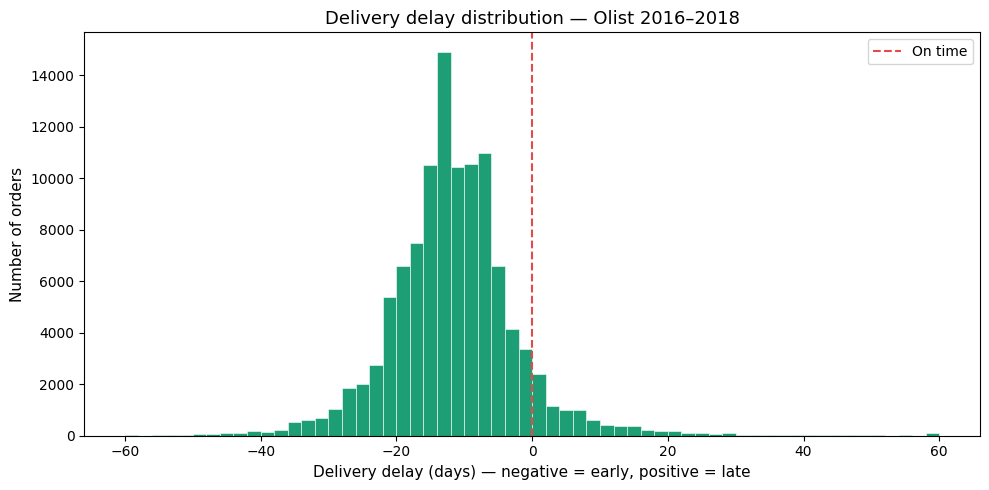

Chart saved!


In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 5))

# Plot delay distribution — clip to -60 to +60 for readability
clipped = df_delivered['delivery_delay_days'].clip(-60, 60)
ax.hist(clipped, bins=60, color='#1D9E75', edgecolor='white', linewidth=0.4)

ax.axvline(0, color='#E24B4A', linewidth=1.5, linestyle='--', label='On time')
ax.set_xlabel('Delivery delay (days) — negative = early, positive = late', fontsize=11)
ax.set_ylabel('Number of orders', fontsize=11)
ax.set_title('Delivery delay distribution — Olist 2016–2018', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig(r'E:\Nile Tech\DataAnalyst90Days\Phase1_Olist\images\delivery_delay_dist.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")